(sec-sup-top)=

<div align="center">
    <h1>Supervised Learning </h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <a href="https://colab.research.google.com/github/SECQUOIA/PU_CHE597_DSinChemE/blob/main/14-Supervised/Supervised.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

# Table of Contents
- [Supervised Learning](#sec-sup-main)
  - [Support Vector Machines](#sec-sup-svm)
    - [Sample Datasets](#sec-sup-samples)
    - [scikit-learn example](#sec-sup-sklearn)
    - [Multitask Example](#sec-sup-multi)
    - [Kernel Trick](#sec-sup-kernel)
    - [Activity 1 - Kernel Trick](#sec-sup-act1)
  - [Artificial Neural Networks](#sec-sup-ann)
    - [Accuracy vs Loss](#sec-sup-accloss)
    - [Problem Context](#sec-sup-context)
    - [Activity 2 - Calculate Statistics](#sec-sup-act2)
    - [Activity 3 - Standardize Data](#sec-sup-act3)
    - [Training and Testing Split](#sec-sup-split)
    - [Single Layer Neural Network](#sec-sup-single)
    - [Activity 4 - Compile a Multilayer Perceptron Model](#sec-sup-act4)
  - [References](#references)


In [1]:
from sklearn.metrics import jaccard_score, accuracy_score, recall_score, precision_score, f1_score, balanced_accuracy_score
import numpy as np

y_label = np.array([0,0,1,1,2,2])
y_pred  = np.array([1,1,1,1,1,2])

print("A:",accuracy_score(y_label,y_pred))
print("P:",precision_score(y_label,y_pred,average=None))
print("R:",recall_score(y_label,y_pred,average=None))
print("J:",jaccard_score(y_label,y_pred,average=None))
print("F1:",f1_score(y_label,y_pred,average=None))


A: 0.5
P: [0.  0.4 1. ]
R: [0.  1.  0.5]
J: [0.  0.4 0.5]
F1: [0.         0.57142857 0.66666667]


/home/bernalde/miniconda3/envs/PU-DSinChemE/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


**Check your understanding:** Why can accuracy be misleading for imbalanced classes?


In [2]:
# Mini-exercise
# Compute balanced accuracy for a toy example.
y_true = np.array([0, 0, 0, 1])
y_pred = np.array([0, 0, 0, 0])
bal_acc = 0.0  # TODO: replace with balanced_accuracy_score(y_true, y_pred)
print(bal_acc)
# Expected output: 0.5


0.0


In [3]:
y_label = np.array([0,0,0,0,1,1,1,1])
y_pred  = np.array([0,0,0,0,1,1,1,0])

print("A:",accuracy_score(y_label,y_pred))
print("P:",precision_score(y_label,y_pred,average=None))
print("R:",recall_score(y_label,y_pred,average=None))
print("J:",jaccard_score(y_label,y_pred,average=None))
print("F1:",f1_score(y_label,y_pred,average=None))
print(8/9)
print(6/7)

A: 0.875
P: [0.8 1. ]
R: [1.   0.75]
J: [0.8  0.75]
F1: [0.88888889 0.85714286]
0.8888888888888888
0.8571428571428571


(sec-sup-main)=
## Supervised Learning ##
Supervised learning is one of the four common branches of machine learning concerned with predicting future observations based on labeled data. In a typical application, we choose descriptors (features), select a model, and decide on an optimal training strategy.

<b>feature selection</b>: the process of deciding on inputs used for training our model. In the most general case, we seek a model $f(\mathbf{x})=\mathbf{y}$, where $\mathbf{x}$ is the set of features and $\mathbf{y}$ is the set of labels we want to predict. The choice of $\mathbf{x}$ may be obvious in some cases (e.g., physical laws that underlie target phenomena), but in many cases it is guided by data availability and trial and error.

<b>model selection</b>: many varieties of supervised learning models exist, each with strengths and weaknesses. Models are differentiated based on whether we are interested in classification ($\mathbf{y}$ is a set of discrete labels or classes) or regression ($\mathbf{y}$ is a set of scalar labels). Finding the "best" model is not usually the goal, rather finding a model that performs well for the task. Model selection is often based on considerations like ease of training, prior expertise, and demonstrated performance on related tasks with similar domains.

<b>training</b>: the specific algorithm used for optimization can have an enormous impact on model performance. Training algorithms can be specific to the model, however most build on concepts from optimization (e.g., gradient descent, stochastic, batch, momentum). Data splitting, regularization, and cross-validation are critical tools for reducing overfitting and obtaining good general performance.

<b>error</b>: in supervised learning, the target property is well defined and provides a clear metric for performance. Typical objective functions include penalties related to misclassification or deviation from labels (e.g., mean squared error or absolute difference in regression tasks).

Supervised learning is the most common branch of machine learning and underlies many commercial uses of ML. Today we will cover two examples: <b>support vector machines</b> and <b>neural networks</b>.


Text(0.5, 1.0, 'non-linear separable')

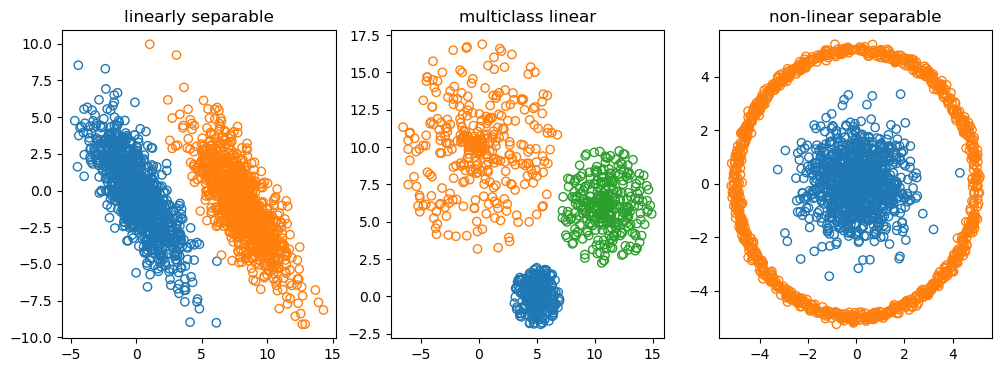

In [4]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_hyperplane(clf, min_x, max_x, linestyle, label):
    for i in range(len(clf.coef_)):
        # get the separating hyperplane
        w = clf.coef_[i]
        a = -w[0] / w[1]
        xx = np.linspace(min_x, max_x)  # make sure the line is long enough
        yy = a * xx - (clf.intercept_[i]) / w[1]
        plt.plot(xx, yy, linestyle, label=label)

# define rotation function for generating datasets
def rotate(a,angle,mode='degree'):
    if len(a.shape) == 1 or a.shape[1] != 2:
        raise ValueError("ERROR in rotate: input matrix must be Nx2")
    if mode == "angle":
        angle = angle*np.pi/180.0
    return np.einsum('...i,ij',a,np.array([[np.cos(angle),-np.sin(angle)],[np.sin(angle),np.cos(angle)]]))

num = 1000
plt.figure(figsize=(12, 4))

# Generate dataset 1 : offset gaussians
a = np.concatenate([np.random.normal(loc=0.0,scale=3.0,size=(num,1)),np.random.normal(loc=0.0,scale=1.0,size=(num,1))],axis=1)
a = rotate(a,45) 
b = np.concatenate([np.random.normal(loc=0.0,scale=3.0,size=(num,1)),np.random.normal(loc=0.0,scale=1.0,size=(num,1))],axis=1)
b = rotate(b,45) + np.array([8.0,-1.0])
data1_X = np.concatenate([a,b],axis=0)
data1_y = np.array([0]*len(a) + [1]*len(b))
plt.subplot(131)
plt.scatter(data1_X[:,0],data1_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(list(data1_y)))
plt.title('linearly separable')

# Generate dataset 2 : blobs with varying density
r = np.random.uniform(low=0.0,high=2.0,size=(int(num/3),1))
theta = np.random.uniform(low=0.0,high=np.pi*2.0,size=(int(num/3),1))
a = np.concatenate([r*np.cos(theta),r*np.sin(theta)],axis=1) + np.array([5.0,0])
r = np.random.uniform(low=0.0,high=7.0,size=(int(num/3),1))
theta = np.random.uniform(low=0.0,high=np.pi*2.0,size=(int(num/3),1))
b = np.concatenate([r*np.cos(theta),r*np.sin(theta)],axis=1) + np.array([0.0,10.0])
r = np.random.uniform(low=0.0,high=4.0,size=(int(num/3),1))
theta = np.random.uniform(low=0.0,high=np.pi*2.0,size=(int(num/3),1))
c = np.concatenate([r*np.cos(theta),r*np.sin(theta)],axis=1) + np.array([11.0,6.0])
data2_X = np.concatenate([a,b,c],axis=0)
data2_y = np.array([0]*len(a) + [1]*len(b) + [2]*len(c))
plt.subplot(132)
plt.scatter(data2_X[:,0],data2_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(list(data2_y)))
plt.title('multiclass linear')

# Generate dataset 3 : ring with bullseye
a = np.concatenate([np.random.normal(loc=0.0,scale=1.0,size=(num,1)),np.random.normal(loc=0.0,scale=1.0,size=(num,1))],axis=1)
r = np.random.normal(loc=5.0,scale=0.1,size=(num,1))
theta = np.random.uniform(low=0.0,high=np.pi*2.0,size=(num,1))
b = np.concatenate([r*np.cos(theta),r*np.sin(theta)],axis=1)
data3_X = np.concatenate([a,b],axis=0)
data3_y = np.array([0]*len(a) + [1]*len(b))
plt.subplot(133)
plt.scatter(data3_X[:,0],data3_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(list(data3_y)))
plt.title('non-linear separable')

(sec-sup-sklearn)=
#### scikit-learn example ###
The cell below demonstrates how to use the scikit-learn `SVC` object to perform linear classification.


Text(0.5, 1.0, 'SVM Prediction')

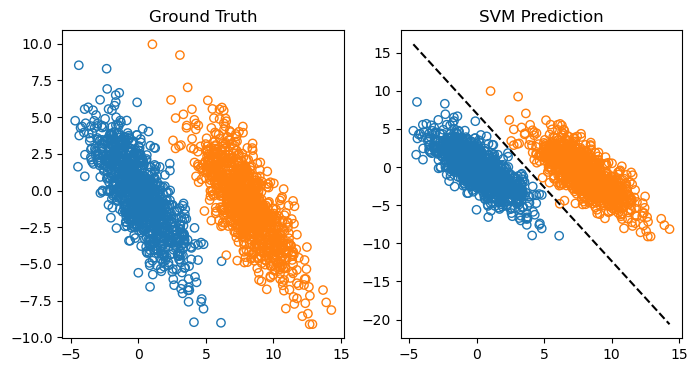

In [5]:
from sklearn.svm import SVC

# Initialize SVM model and fit
model = SVC(kernel='linear')
model.fit(data1_X,data1_y)

# Plot original data with labels
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.scatter(data1_X[:,0],data1_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(list(data1_y)))
plt.title('Ground Truth')

# Plot SVM predictions
plt.subplot(122)
plt.scatter(data1_X[:,0],data1_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(model.predict(data1_X)))
plot_hyperplane(model, min(data1_X[:,0]), max(data1_X[:,0]), 'k--','Boundary\nfor class 1')
plt.title('SVM Prediction')

Mini-exercise: Fit an SVM with a different C value and report accuracy.


In [6]:
# Mini-exercise
# Fit SVM with a different C and report accuracy.
if 'data1_X' in globals() and 'data1_y' in globals():
    from sklearn.svm import SVC
    C = 1.0  # TODO: change C
    model = SVC(kernel='linear', C=C)
    model.fit(data1_X, data1_y)
    acc = 0.0  # TODO: replace with model.score(data1_X, data1_y)
    print(acc)
else:
    print('TODO: run the SVM dataset cell above')
# Expected output: a float accuracy.


0.0


(sec-sup-multi)=
#### Multitask Example ####
In scikit-learn, training SVMs for multiclass assignment is almost identical to the two-class case:


Text(0.5, 1.0, 'SVM Prediction')

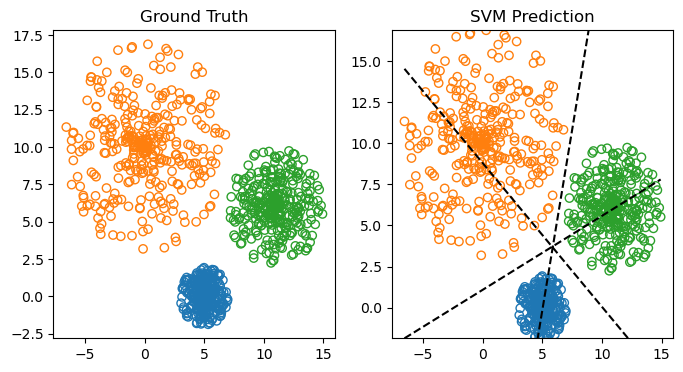

In [7]:
from sklearn.svm import SVC

# Initialize SVM model and fit
model = SVC(kernel='linear')
model.fit(data2_X,data2_y)

# Plot original data with labels
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.scatter(data2_X[:,0],data2_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(list(data2_y)))
plt.title('Ground Truth')

# Plot SVM predictions
plt.subplot(122)
plt.scatter(data2_X[:,0],data2_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(model.predict(data2_X)))
plot_hyperplane(model, min(data2_X[:,0]), max(data2_X[:,0]), 'k--','Boundary\nfor class 1')
plt.ylim(min(data2_X[:,1]),max(data2_X[:,1]))
plt.title('SVM Prediction')

**Check your understanding:** How does multiclass SVM training relate to the one-vs-one strategy?


<b>Note:</b> It is messy to try and draw the boundaries so that they don't overlap. Technically, the dotted lines should radiate out from the crossing, not pass through it.

(sec-sup-kernel)=
#### Kernel Trick ####
The so-called "kernel trick" is used for linearizing non-linear problems. In simple terms this lets you determine curved boundaries with SVMs. In principle these are expensive to calculate, but by applying the transform virtually (via the kernel) these curved boundaries can be calculated efficiently. The results will depend on the specific kernel that you use.

Note: See scikit-learn SVM kernels: https://scikit-learn.org/stable/modules/svm.html#svm-kernels


Text(0.5, 1.0, 'sigmoid')

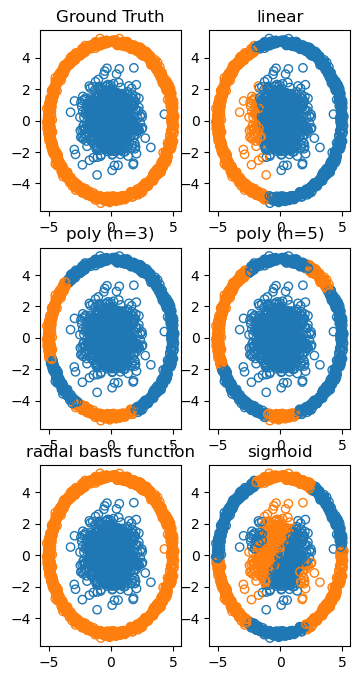

In [8]:
from sklearn.svm import SVC


# Plot original data with labels
plt.figure(figsize=(4, 8))
plt.subplot(321)
plt.scatter(data3_X[:,0],data3_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(list(data3_y)))
plt.title('Ground Truth')

# Plot results with linear kernel
model = SVC(kernel='linear')
model.fit(data3_X,data3_y)
plt.subplot(322)
plt.scatter(data3_X[:,0],data3_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(model.predict(data3_X)))
plt.title('linear')

# Plot results with linear kernel
model = SVC(kernel='poly',gamma='scale',degree=3)
model.fit(data3_X,data3_y)
plt.subplot(323)
plt.scatter(data3_X[:,0],data3_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(model.predict(data3_X)))
plt.title('poly (n=3)')

# Plot results with linear kernel
model = SVC(kernel='poly',gamma='scale',degree=5)
model.fit(data3_X,data3_y)
plt.subplot(324)
plt.scatter(data3_X[:,0],data3_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(model.predict(data3_X)))
plt.title('poly (n=5)')

# Plot results with linear kernel
model = SVC(kernel='rbf',gamma='scale')
model.fit(data3_X,data3_y)
plt.subplot(325)
plt.scatter(data3_X[:,0],data3_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(model.predict(data3_X)))
plt.title('radial basis function')

# Plot results with linear kernel
model = SVC(kernel='sigmoid',gamma='scale')
model.fit(data3_X,data3_y)
plt.subplot(326)
plt.scatter(data3_X[:,0],data3_X[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(model.predict(data3_X)))
plt.title('sigmoid')

**Check your understanding:** Which kernel gave the best separation in your plots?


Mini-exercise: Try a different kernel on the bullseye dataset.


In [9]:
# Mini-exercise
# Fit SVM with RBF kernel on data3.
if 'data3_X' in globals() and 'data3_y' in globals():
    from sklearn.svm import SVC
    gamma = 'scale'  # TODO: try a numeric value
    model = SVC(kernel='rbf', gamma=gamma)
    model.fit(data3_X, data3_y)
    acc = 0.0  # TODO: replace with model.score(data3_X, data3_y)
    print(acc)
else:
    print('TODO: run the kernel trick section above')
# Expected output: a float accuracy.


0.0


<b>Q1</b>: Which kernel works best at separating the data?

<b>Q2</b>: Did you notice a difference in the run time for the non-linear kernels?

(sec-sup-ann)=
### Artificial Neural Networks ###
The fundamental unit in a neural network is the "artificial neuron". These artificial neurons are the mathematical analog of their biological counterparts. They link to other neurons and "fire" depending on whether their inputs rise above a threshold. A neural network can be made up of thousands of these neurons connected in different ways. The basic parameters are the weights for each connection (a scalar that scales the connection between a pair of neurons) and the bias in the activation function (the threshold necessary to switch the neuron).

Neural networks map features to labels via the input and output layers. Contrast this with support vector machines, where the model fits a boundary and predictions are based on which side of the boundary they reside. Any layers between input and output are referred to as "hidden". Models with hidden layers are called "deep", and their proficiency in mapping complex relationships has created the term "deep learning". Although neural networks can in principle be arranged in many structures, implementation is aided by common architectures (e.g., feed-forward and convolutional networks).

Sufficiently large neural networks can approximate any function. The compelling idea behind much of deep learning is that neural networks can learn $f(x)=y$ mappings for models that are intrinsically too complex for direct physical modeling. Conversely, the complexity of deep models makes them difficult to train, which historically limited their use. Deep neural networks are also firmly in culture 2 (if you think back to the first lecture)—they are not easily interpretable, but are trained for predictive performance.

Several specialized libraries support the development of neural network models. Here we use the `Keras` Python API with a `tensorflow` backend.

Note: Keras API: https://keras.io/api/


(sec-sup-accloss)=
#### Accuracy vs Loss ####
As objective functions become more complex, we distinguish between the value of the objective function and performance on the prediction task. Specifically:

<b>loss</b>: the value of the objective function the training algorithm is minimizing.

<b>accuracy</b>: the accuracy of the model on the prediction task we care about (e.g., classification accuracy).

These two are not always tightly coupled. For instance, regularization terms can change the loss without improving predictive accuracy.

(sec-sup-context)=
#### Problem Context ####
You work as a quality engineer for a company that builds pumps for industrial applications. As part of your job, you perform failure testing to determine if pumps are in or out of specifications. This testing is destructive, so you wonder if there is a data-driven way to improve quality control.

At your disposal is a dataset consisting of measurements taken on 150 pumps, along with labels from the testing process. The data are stored in `features.txt` and `labels.txt` in the same folder as this notebook (downloaded automatically below if missing).

Note: Keras Sequential/Model API: https://keras.io/api/models/


In [10]:
import os
import pandas as pd

# Download files if missing
for fname in ['features.txt', 'labels.txt']:
    if not os.path.exists(fname):
        !wget -q https://raw.githubusercontent.com/SECQUOIA/PU_CHE597_DSinChemE/main/13-Classification/{fname} -O {fname}

# Assign labels. Within the data set, an 'F' denotes a failed test, 'R' denotes that the pump did not pass, but
# is within acceptable parameters to rework, and 'P' denotes a pass. These character labels are converted to
# numerical labels for analysis.
label_dictionary = {'F': 0, 'R': 1, 'P': 2}

# Header from data file
feature_names = ['Inlet_Diameter_(cm)', 'Maximum_Capacity_(GPM)', 'Max_Head_(ft)', 'Minimum_Thickness_(mm)']

# Load data
features_df = pd.read_csv('features.txt', delimiter=r"\s+")
labels_raw = pd.read_csv('labels.txt', header=None)[0]

features = features_df.to_numpy()
labels = labels_raw.map(label_dictionary).to_numpy()

print(f"features shape: {features.shape}")
print(f"labels shape: {labels_raw.shape}")
print(f"class counts: {labels_raw.value_counts().to_dict()}")


features shape: (150, 4)
labels shape: (150,)
class counts: {'P': 50, 'R': 50, 'F': 50}


We expect our pump to operate within a certain set of tolerances. If the inlet diameter is too small or too large, it can adversely affect the pump capacity. Within the acceptable inlet diameter range, we can accept some fluctuation in capacity. If the maximum head (analogous to maximum pressure) is very high but the minimum thickness of the pump is too small, the pump will fail during testing.

(sec-sup-act2)=
#### Activity 2 - Calculate Statistics ####
1. Use the cell below to calculate the mean and standard deviation of each feature. 
2. Make plots of the diameter vs capacity and head vs thickness.

Average Inlet_Diameter_(cm) : 15.14 +/- 0.48
Average Maximum_Capacity_(GPM) : 14700.10 +/- 189.10
Average Max_Head_(ft) : 542.92 +/- 1.51
Average Minimum_Thickness_(mm) : 10.34 +/- 0.47


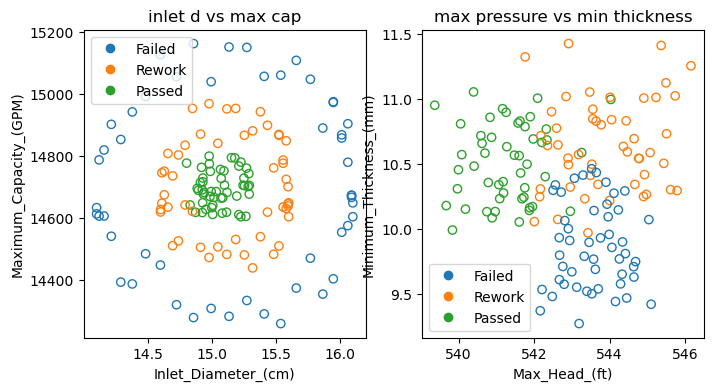

In [11]:
import matplotlib.lines as mlines

# calculate and print summary stats
mean = np.mean(features,axis=0)
std = np.std(features,axis=0)
for i in range(len(features[0,:])):
        print('Average {} : {:.2f} +/- {:.2f}'.format(feature_names[i],mean[i],std[i]))

# Initialize dots for legend
fail = mlines.Line2D([],[],color=cm.tab10(0), marker= 'o',linestyle='None',label='Failed')
rework = mlines.Line2D([],[],color=cm.tab10(1),marker='o',linestyle='None',label='Rework')
passed = mlines.Line2D([],[],color=cm.tab10(2),marker='o',linestyle='None',label='Passed')

# Make plots
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.scatter(features[:,0],features[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(labels))
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title('inlet d vs max cap')
plt.legend(handles=[fail,rework,passed])

plt.subplot(122)
plt.scatter(features[:,2],features[:,3],facecolor='None',marker='o',edgecolors=cm.tab10(labels))
plt.xlabel(feature_names[2])
plt.ylabel(feature_names[3])
plt.title('max pressure vs min thickness')
plt.legend(handles=[fail,rework,passed])



**Check your understanding:** Which feature has the largest standard deviation?


In [12]:
# Mini-exercise
# Report the index of the largest feature standard deviation.
if 'std' in globals():
    idx = 0  # TODO: use np.argmax(std)
    print(idx)
else:
    print('TODO: run the statistics cell above')
# Expected output: integer index (0-3)


0


<b>Q1</b>: Do you see a relationship between the four features and the failure testing? Is it linear or non-linear?

<b>Q2</b>: Do the features have the same scale? If not, what should we do before building our model?

(sec-sup-act3)=
#### Activity 3 - Standardize Data ####
In the cell below standardize the features and replot the results

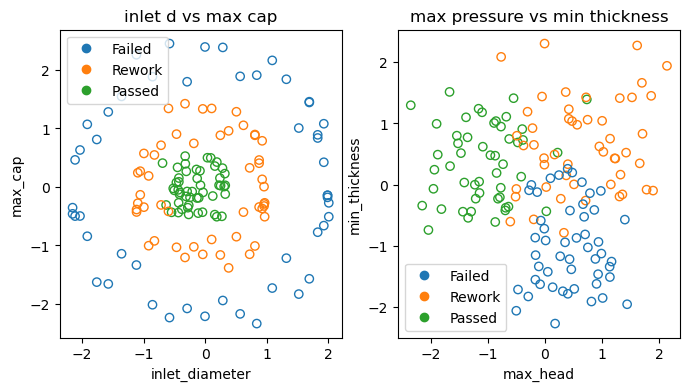

In [13]:
# Standardize the data (since it is an array we can do it in one line)
std_features = (features-mean)/std

# Make plots of standardized data
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.scatter(std_features[:,0],std_features[:,1],facecolor='None',marker='o',edgecolors=cm.tab10(labels))
plt.xlabel("inlet_diameter")
plt.ylabel("max_cap")
plt.title('inlet d vs max cap')
plt.legend(handles=[fail,rework,passed])

plt.subplot(122)
plt.scatter(std_features[:,2],std_features[:,3],facecolor='None',marker='o',edgecolors=cm.tab10(labels))
plt.xlabel("max_head")
plt.ylabel("min_thickness")
plt.title('max pressure vs min thickness')
plt.legend(handles=[fail,rework,passed])


**Check your understanding:** Why does standardization help gradient-based training?


(sec-sup-split)=
#### Training and Testing Split ####

When training a neural network, we would like to use as much data as possible so that our model can learn on as representative a dataset as possible. However, it is also vital to ensure that the model is capable of accurate predictions on data that it has not seen before, as this matches how the model will be applied in practice. 

We will make a simple 80:20 training:testing split to use for parameterizing and evaluating our model. scikit-learn can do this for us in one step using the `train_test_split` function in the `model_selection` library

Note: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html


In [14]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(std_features, labels, test_size=0.20)

**Check your understanding:** What happens if you change the test split size?


In [15]:
# Mini-exercise
# Create a different split and report sizes.
if 'std_features' in globals() and 'labels' in globals():
    test_size = 0.3  # TODO: change test size
    tx, vx, ty, vy = train_test_split(std_features, labels, test_size=test_size, random_state=42)
    print(tx.shape, vx.shape)
else:
    print('TODO: run the standardization cell above')
# Expected output: train/test shapes


(105, 4) (45, 4)


(sec-sup-single)=
#### Single Layer Neural Network ####
For this model, we will utilize a single, fully connected layer of 3 units. That is, each input parameter is fed to each of the 3 units. The units do no communicate amongst each other. Each will use some linear combination of the inputs fed to them multiplied by a weighting factor, and will mediate their output through a nonlinear activation function. Here, because we are considering a classification task, we utilize the 'softmax' activation function. This will output a set of normalized probability values ( i.e. 0.3,0.5,0.2 ) corresponding to the probability that a given class has been observed.

Such models are trained through a process called backpropagation, whereby the error in the network output is used to calculate derivatives of the error with respect to the layer weights. These derivatives are used to update the weights using stochastic gradient descent (SGD) in an iterative fashion to reduce the error. Because we are dealing with a classification task with three possible outputs (Pass,Rework,Fail) we utilize the categorical crossentropy loss function, which penalizes output distributions that diverge from the input distribution. We use an 'accuracy' metric to see how accurate the model is in predicting the input class. 

Note: Input layer is not considered when discussing network depth. Only those layers that can be trained (i.e., hidden layers) are relevant.

In [16]:
from keras.layers import Input,Dense
from keras.optimizers import SGD
from keras.models import Model
from keras.utils import to_categorical

input_layer = Input(shape=(4,))
output_layer = Dense(3,activation = 'softmax')(input_layer) # NOTE: second parenthesis tells keras which layer to connect this to.
model_1 = Model(inputs=input_layer,outputs=output_layer)
model_1.compile(loss='categorical_crossentropy',optimizer=SGD(learning_rate=1e-2),metrics=['accuracy'])
model_1.summary()

2026-01-30 15:49:30.342632: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 15:49:30.511413: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1769806173.271126  585550 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5658 MB memory:  -> device: 0, name: NVIDIA RTX A1000, pci bus id: 0000:55:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

We can view a summary of our compiled model above, describing the topology and other relevant features. It is often a good idea to check that the different layers are connected correctly in more complicated models. 

Now lets train the model. We will pass our training data through the network 150 times, or for 150 epochs, and we will pass one datum at a time (SGD). We can pass our test set data through as 'validation data' to see how our model would perform on unseen data. 

In [17]:
#NOTE: To restart training, you must recompile the model. Repeated fit calls will update the existing model
history=model_1.fit(x=train_x,y = to_categorical(train_y),epochs=150,verbose=1,batch_size=1,validation_data =[test_x,to_categorical(test_y)] )
print(f"final train acc: {history.history['accuracy'][-1]:.3f}")
print(f"final val acc: {history.history['val_accuracy'][-1]:.3f}")


Epoch 1/150


2026-01-30 15:49:34.510393: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a905c005b30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-30 15:49:34.510433: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A1000, Compute Capability 8.6
2026-01-30 15:49:34.552804: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-30 15:49:34.600632: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700


 67/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2261 - loss: 1.5415    

I0000 00:00:1769806174.847638  585688 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3417 - loss: 1.3104 - val_accuracy: 0.2333 - val_loss: 1.1580
Epoch 2/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4667 - loss: 0.9020 - val_accuracy: 0.6333 - val_loss: 0.8341
Epoch 3/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7583 - loss: 0.6981 - val_accuracy: 0.7667 - val_loss: 0.6761
Epoch 4/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8083 - loss: 0.5975 - val_accuracy: 0.7667 - val_loss: 0.5931
Epoch 5/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8333 - loss: 0.5416 - val_accuracy: 0.8333 - val_loss: 0.5433
Epoch 6/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8333 - loss: 0.5067 - val_accuracy: 0.8333 - val_loss: 0.5102
Epoch 7/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8417 - loss: 0.4826 - val_accuracy: 0.8333 - val_loss: 0.4867
Epoch 8/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8417 - loss: 0.4655 - val_accuracy: 0.8333

**Check your understanding:** Is validation accuracy stable across epochs?


Text(0.5, 0, 'Epoch')

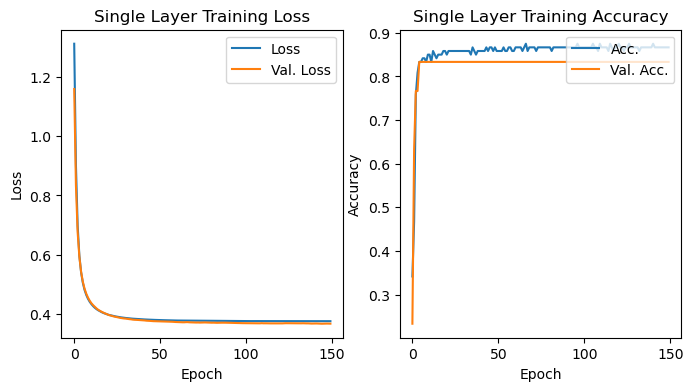

In [18]:

# Make loss plot
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.plot(history.history['loss'],label='Loss')
plt.plot(history.history['val_loss'],label='Val. Loss')
plt.legend(loc='upper right')
plt.title('Single Layer Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

# Make accuracy plot
plt.subplot(122)
plt.plot(history.history['accuracy'],label='Acc.')
plt.plot(history.history['val_accuracy'],label='Val. Acc.')
plt.legend(loc='upper right')
plt.title('Single Layer Training Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')


The printed validation accuracy above shows the performance limit of the single-layer model on this split. The model is not complex enough to learn the full relationships between the pump testing features and results.

<b>Q1</b>: We see the validation loss start to increase in this example. What does this mean?

<b>Q2</b>: What is the difference between loss and accuracy?


In [19]:
#input_layer = Input(shape=(4,))
#output_layer = Dense(3,activation = 'softmax')(input_layer) # NOTE: second parenthesis tells keras which layer to connect this to.
#model_2 = Model(inputs=input_layer,outputs=output_layer)
#model_2.compile(loss='categorical_crossentropy',optimizer=SGD(learning_rate=1e-2),metrics=['accuracy'])
#model_2.summary()

input_layer = Input(shape=(4,))
hidden_layer = Dense(8,activation='relu')(input_layer)
hidden_layer_2 = Dense(8,activation ='relu')(hidden_layer)
output_layer = Dense(3,activation = 'softmax')(hidden_layer_2)
model_2 = Model(inputs=input_layer,outputs=output_layer)
model_2.compile(loss='categorical_crossentropy',optimizer=SGD(learning_rate=1e-2),metrics=['accuracy'])

model_2.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139 (556.00 B)

 Trainable params: 139 (556.00 B)

 Non-trainable params: 0 (0.00 B)

Check the output summary to make sure that your model is connected properly. Now let's train our model and plot its performance. This time we'll use 300 epochs since it is a more complex model and may take longer to train. 

In [20]:
history=model_2.fit(x=train_x,y = to_categorical(train_y),epochs=300,verbose=1,batch_size=1,validation_data=[test_x,to_categorical(test_y)])
print(f"final train acc: {history.history['accuracy'][-1]:.3f}")
print(f"final val acc: {history.history['val_accuracy'][-1]:.3f}")


Epoch 1/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4417 - loss: 1.0461 - val_accuracy: 0.6000 - val_loss: 0.9589
Epoch 2/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7000 - loss: 0.8644 - val_accuracy: 0.8000 - val_loss: 0.7639
Epoch 3/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7667 - loss: 0.6949 - val_accuracy: 0.8000 - val_loss: 0.6115
Epoch 4/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7917 - loss: 0.5819 - val_accuracy: 0.8000 - val_loss: 0.5151
Epoch 5/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8500 - loss: 0.5051 - val_accuracy: 0.8667 - val_loss: 0.4503
Epoch 6/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8750 - loss: 0.4491 - val_accuracy: 0.8667 - val_loss: 0.3968
Epoch 7/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8667 - loss: 0.4122 - val_accuracy: 0.8667 - val_loss: 0.3554
Epoch 8/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8917 - loss: 0.3783 - val_accu

**Check your understanding:** How does adding hidden layers change the bias-variance tradeoff?


Text(0.5, 0, 'Epoch')

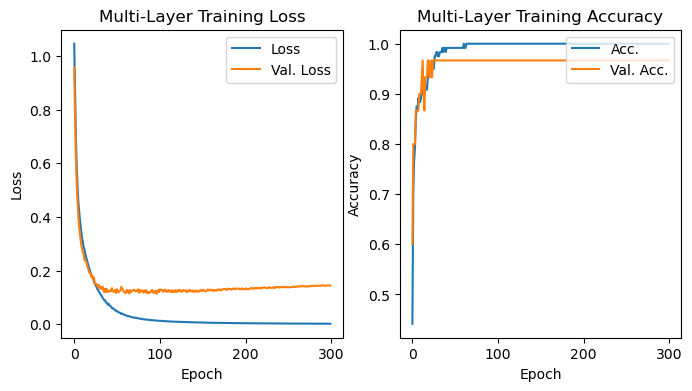

In [21]:

# Make loss plot
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.plot(history.history['loss'],label='Loss')
plt.plot(history.history['val_loss'],label='Val. Loss')
plt.legend(loc='upper right')
plt.title('Multi-Layer Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

# Make accuracy plot
plt.subplot(122)
plt.plot(history.history['accuracy'],label='Acc.')
plt.plot(history.history['val_accuracy'],label='Val. Acc.')
plt.legend(loc='upper right')
plt.title('Multi-Layer Training Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')


            Use the printed validation accuracy above to compare the multilayer model with the single-layer model.

<b>Q1</b>: Why does the multilayer model perform better?

<b>Q2</b>: What are some downsides of using a multilayer model compared with a single layer?


## References
- https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics
- https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- https://scikit-learn.org/stable/modules/svm.html#svm-kernels
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- https://keras.io/api/models/
- https://keras.io/api/layers/
- https://keras.io/api/utils/
